In [1]:
import torch
import torch.nn as nn
import pytorch_lightning as pl
from torchmetrics.image.fid import FrechetInceptionDistance
from pytorch_lightning.callbacks import ModelCheckpoint
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import os
from pytorch_lightning.loggers import TensorBoardLogger
# torch.set_float32_matmul_precision('high')
%load_ext tensorboard

#### DATA IMPORT AND PREPROCESSING

In [2]:
generator = torch.Generator().manual_seed(42)

trf = transforms.Compose([
    transforms.ToTensor(), # map 255 channel values in [0,1]
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # map the [0,1] interval in [-1,1], dati centrati su 0, niente sigmoide in output
])

ds_tr = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=trf)
ds_te = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=trf)

batch_size = 128
val_size = 6 * batch_size
train_size = len(ds_tr) - val_size

ds_tr_split, ds_val_split = random_split(ds_tr, [train_size, val_size], generator=generator)

ldr_tr = DataLoader(ds_tr_split, batch_size=batch_size, shuffle=True, num_workers=5, pin_memory=True)
ldr_val = DataLoader(ds_val_split, batch_size=batch_size, shuffle=False, num_workers=4)
ldr_te = DataLoader(ds_te, batch_size=batch_size, shuffle=False, num_workers=4)

In [ ]:
def visualize_batch(loader, n):
    batch = next(iter(loader))
    immagini = batch[0]
    img = immagini[n]
    img = (img * 0.5) + 0.5
    img = img.permute(1, 2, 0)
    plt.imshow(img.numpy())
    plt.axis('off')
    plt.show()

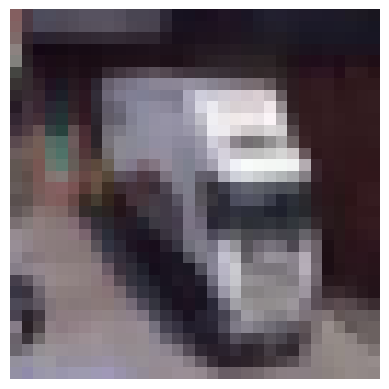

In [ ]:
visualize_batch(ldr_val, 9)

#### MODEL DEFINITION

In [5]:
class VAE(pl.LightningModule):
    def __init__(self, z_dim=128, beta=1.0, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()

        # the layer scaling is done following the DCGAN standard by halving the spatial size at every convolution.
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.Flatten(),
        )
        # estimate the mean and variance of the latent distribution
        self.fc_mu = nn.Linear(4 * 4 * 256, z_dim)
        self.fc_logvar = nn.Linear(4 * 4 * 256, z_dim)

        self.decoder = nn.Sequential(
            nn.Linear(z_dim, 256 * 4 * 4),
            nn.Unflatten(1, (256, 4, 4)),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )

        self.beta = beta
        self.lr = lr
        self.z_dim = z_dim

    def configure_optimizers(self):
        opt = torch.optim.Adam(self.parameters(), lr=self.lr, betas=(0.5, 0.999))
        return opt

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z)

    def reconstruct(self, x):
        # deterministic reconstruction: decode the posterior mean
        mu, _ = self.encode(x)
        return self.decoder(mu)

    def sample(self, num_smpl):
        z = torch.randn(num_smpl, self.z_dim).to(self.device)
        return self.decoder(z)

    def training_step(self, batch, batch_idx):
        x, _ = batch

        # forward pass
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_rec = self.decoder(z)

        # reconstruction loss
        loss_rec = F.mse_loss(x_rec, x)

        # KL divergence regularization
        kld = -0.5 * torch.mean(torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1))

        loss = loss_rec + self.beta * kld

        self.log_dict({'loss': loss, 'recon_loss': loss_rec, 'kld': kld})
        return loss


class FIDCallback(pl.Callback):
    def __init__(self, val_loader, smpl):
        super().__init__()
        self.val_loader = val_loader
        self.smpl = smpl

    def on_train_epoch_end(self, trainer, pl_module):
        # FID + sample grid
        fid_score, img_vis = compute_fid_score(pl_module, self.val_loader, self.smpl, pl_module.device)
        pl_module.log("val_fid", fid_score, on_step=False, on_epoch=True, prog_bar=False)
        grid = torchvision.utils.make_grid(img_vis, nrow=4)
        trainer.logger.experiment.add_image("generated_images", grid, global_step=trainer.global_step)

        # reconstruction grid: original row on top, reconstruction row below
        x, _ = next(iter(self.val_loader))
        x = x[:8].to(pl_module.device)
        with torch.no_grad():
            x_rec = pl_module.reconstruct(x)
        pair = torch.cat([x, x_rec], dim=0)
        pair = ((pair * 0.5 + 0.5) * 255).to(torch.uint8).cpu()
        grid_rec = torchvision.utils.make_grid(pair, nrow=8)
        trainer.logger.experiment.add_image("reconstructions", grid_rec, global_step=trainer.global_step)

        pl_module.train()


def compute_fid_score(model, loader, num_samples, device, batch_size=128):
    model.eval()
    model.to(device)
    fid_metric = FrechetInceptionDistance(feature=2048).to(device)

    img_vis = []

    with torch.no_grad():
        for i in range(0, num_samples, batch_size):
            curr_batch_size = min(batch_size, num_samples - i)
            img_gen_batch = model.sample(num_smpl=curr_batch_size)
            img_gen_batch = ((img_gen_batch * 0.5 + 0.5) * 255).to(torch.uint8)
            if len(img_vis) < 16:
                needed = 16 - len(img_vis)
                img_vis.append(img_gen_batch[:needed].cpu())
            fid_metric.update(img_gen_batch, real=False)

        for img, _ in loader:
            img = img.to(device)
            img = ((img * 0.5 + 0.5) * 255).to(torch.uint8)
            fid_metric.update(img, real=True)

    img_vis_tensor = torch.cat(img_vis, dim=0) if img_vis else torch.empty(0)

    return fid_metric.compute(), img_vis_tensor[:16]


def compute_sharpness_score(model, device, smpl):
    model.eval()
    model.to(device)
    laplacian_kernel = torch.tensor([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=torch.float32).view(1, 1, 3, 3).to(device)
    sharpness_scores = []

    with torch.no_grad():
        img_gen = model.sample(num_smpl=smpl)
        # Grey scale conversion (standard luminance method)
        # formula: Y = 0.299R + 0.587G + 0.114B
        gray = (0.299 * img_gen[:, 0:1, :, :] +
                0.587 * img_gen[:, 1:2, :, :] +
                0.114 * img_gen[:, 2:3, :, :])

        laplacian = F.conv2d(gray, laplacian_kernel, padding=1)
        var = laplacian.view(laplacian.size(0), -1).var(dim=1)
        sharpness_scores.append(var.mean().item())
    return sum(sharpness_scores) / len(sharpness_scores)

#### VISUALIZATION FUNCTIONS

In [ ]:
def visualize_samples(model, n=16, nrow=4):
    model.eval()
    with torch.no_grad():
        img = model.sample(num_smpl=n).cpu()
    img = (img * 0.5) + 0.5
    grid = torchvision.utils.make_grid(img, nrow=nrow)
    plt.figure(figsize=(nrow * 1.5, (n // nrow) * 1.5))
    plt.imshow(grid.permute(1, 2, 0).clamp(0, 1).numpy())
    plt.axis('off')
    plt.show()


def visualize_recostruction(model, loader, n=8):
    model.eval()
    x, _ = next(iter(loader))
    x = x[:n].to(model.device)
    with torch.no_grad():
        x_rec = model.reconstruct(x).cpu()
    x = x.cpu()

    x = (x * 0.5) + 0.5
    x_rec = (x_rec * 0.5) + 0.5

    fig, axes = plt.subplots(2, n, figsize=(n * 1.5, 3))
    for i in range(n):
        axes[0, i].imshow(x[i].permute(1, 2, 0).clamp(0, 1).numpy())
        axes[0, i].axis('off')
        axes[1, i].imshow(x_rec[i].permute(1, 2, 0).clamp(0, 1).numpy())
        axes[1, i].axis('off')
    axes[0, 0].set_title('originali', loc='left')
    axes[1, 0].set_title('ricostruzioni', loc='left')
    plt.tight_layout()
    plt.show()

#### MODEL TRAINING

In [12]:
ckpt_dir = "checkpoints"
os.makedirs(ckpt_dir, exist_ok=True)

model = VAE(z_dim=128, beta=0.000001, lr=1e-4)
logger = TensorBoardLogger("tb_logs", name="vae_run")
ckpt_callback = ModelCheckpoint(monitor='val_fid', mode='min', save_top_k=1, filename='best-model-vae', dirpath=ckpt_dir)
fid_callback = FIDCallback(val_loader=ldr_val, smpl=768)
trainer = pl.Trainer(max_epochs=100, callbacks=[ckpt_callback, fid_callback], accelerator="auto", devices=1, logger=logger, enable_progress_bar=False, enable_model_summary=False)

trainer.fit(model, ldr_tr)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/pietro/.my_envs/machine_learning/lib/python3.11/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /home/pietro/universita/Prob_ML/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/pietro/.my_envs/machine_learning/lib/python3.11/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
`Trainer.fit` stopped: `max_epochs=100` reached.


#### MODEL TEST

In [13]:
best_model = VAE.load_from_checkpoint(ckpt_callback.best_model_path)
FID_test, _ = compute_fid_score(best_model, ldr_te, num_samples=len(ldr_te) * 128, device='cuda')
sharp_test = compute_sharpness_score(best_model, 'cuda', 1000)
print(f"FID on test: {FID_test}")
print(f'Sharpness on test: {sharp_test}')

FID on test: 142.53965759277344
Sharpness on test: 0.05321963503956795


#### SAMPLES AND RECONSTRUCTIONS

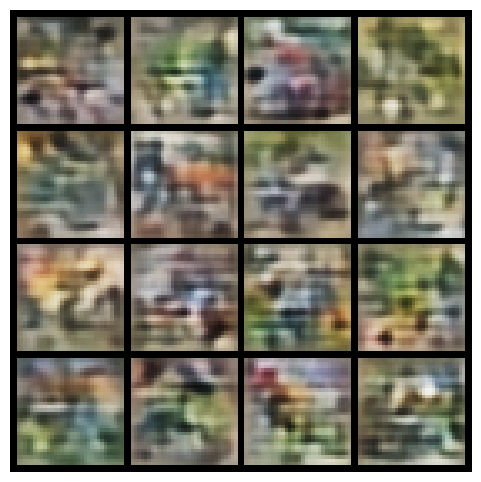

In [ ]:
visualize_samples(best_model, n=16, nrow=4)

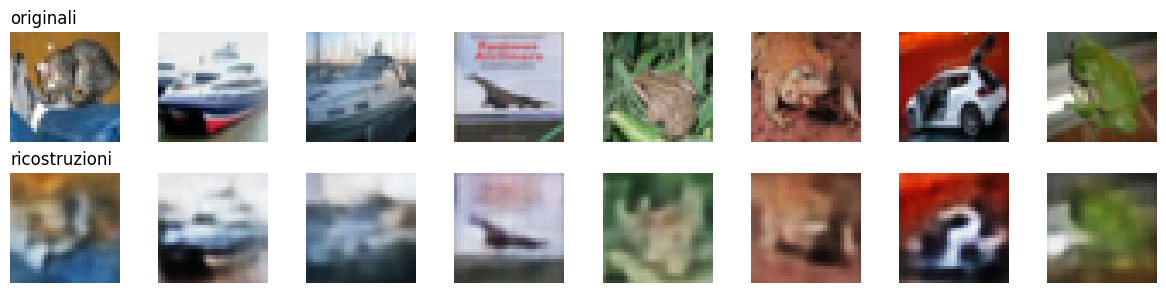

In [ ]:
visualize_recostruction(best_model, ldr_te, n=8)